<a href="https://colab.research.google.com/github/arundhatimsb/assignment/blob/main/sentence_embeddings_sa_en.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 3: Sanskrit-English Sentence Embeddings**

To generate high-quality sentence level embeddings for Sanskrit-English parallel text, **LaBSE** model has been used here.

**LaBSE** : Language-agnostic BERT sentence embedding is the best open source choice for Sanskrit language, because it has been trained on 109 languages including Hindi



# **1. Dependency Installation and Imports**




In [33]:
# Dependency Installation
!pip install torch matplotlib scikit-learn gdown sentence-transformers numpy seaborn --quiet

In [28]:
import gdown
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import matplotlib.patches as mpatches

# **2.   Load Dataset**


In [35]:
# To reproduce the same result
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

folder_id = '1oEYY-Io_8XUBQZXnGftNjseU46Yxc5FK'
gdown.download_folder(
    id=folder_id,
    output='dataset',
    quiet=True,
    use_cookies=False
)

DATA_DIR = 'dataset'

df_train_sa = pd.read_csv(f'{DATA_DIR}/train_sa_10000.csv')
df_train_en = pd.read_csv(f'{DATA_DIR}/train_en_10000.csv')
df_dev_sa   = pd.read_csv(f'{DATA_DIR}/dev_sa_1000.csv')
df_dev_en   = pd.read_csv(f'{DATA_DIR}/dev_en_1000.csv')
df_test_sa  = pd.read_csv(f'{DATA_DIR}/test_sa_1000.csv')
df_test_en  = pd.read_csv(f'{DATA_DIR}/test_en_1000.csv')

print(f"All dataset loaded successfully from the shared drive.")

All dataset loaded successfully from the shared drive.


# **3.   Merge Dataset for data sanitization**




In [40]:
def merge_dataset(df_sa: pd.DataFrame, df_en: pd.DataFrame, dataType='') -> pd.DataFrame:

  # merge similar Source_id with Sentence_sa and Sentence_en
  df = pd.merge(df_sa, df_en, on='Source_id', how='inner')

  # Drop rows with missing text and reset index
  df = df.dropna(subset=['Sentence_sa', 'Sentence_en']).reset_index(drop=True)
  print(f"{dataType}: {len(df)} aligned pairs loaded.")
  return df;

df_train = merge_dataset(df_train_sa, df_train_en, 'Train')
df_dev = merge_dataset(df_dev_sa, df_dev_en, 'Dev')
df_test = merge_dataset(df_test_sa, df_test_en, 'Test')

df_all = pd.concat([df_train, df_dev, df_test], ignore_index=True)
print(f"\nTotal pairs : {len(df_all)}\n")
df_all.head(3)


Train: 10000 aligned pairs loaded.
Dev: 1000 aligned pairs loaded.
Test: 1000 aligned pairs loaded.

Total pairs : 12000



,Source_id,Sentence_sa,Sentence_en
0,1,"""Ctrl, S नुत्वा रक्षन्तु।""","Save it with Ctrl, S."
1,2,गुरुः छात्रान् एकवारं पाठयति ।,Teacher will teach the students only once.
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"To recreate this animation, I have to take two..."


# **4.   Load LaBSE Model**



In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_name = 'sentence-transformers/LaBSE'
model = SentenceTransformer(model_name, device=device)
print(f"Model loaded. Native embedding dimension: {model.get_sentence_embedding_dimension()}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

Model loaded. Native embedding dimension: 768


# **5.   Generate Embeddings(768 native dimensions)**

Sanskrit and english language encoded separately using **LaBSE** here



In [42]:
def encode_sentences(sentences, model, batch_size=64, desc='Encoding'):
  embeddings = model.encode(
      sentences,
      batch_size = batch_size,
      show_progress_bar=True,
      convert_to_numpy=True,
      normalize_embeddings=True,
      device = device
  )
  return embeddings
print("Encoding sanskrit sentences.")
sa_sentences = df_all['Sentence_sa'].tolist()
emb_sa = encode_sentences(sa_sentences,model, desc='Sanskrit')

print("Encoding english sentences.")
en_sentences = df_all['Sentence_en'].tolist()
emb_en = encode_sentences(en_sentences,model, desc='English')

print(f"Native Sanskrit embedding shape : {emb_sa.shape}")
print(f"Native  English  embedding shape : {emb_en.shape}")

Encoding sanskrit sentences.


Batches:   0%|          | 0/188 [00:00<?, ?it/s]

Encoding english sentences.


Batches:   0%|          | 0/188 [00:00<?, ?it/s]

Native Sanskrit embedding shape : (12000, 768)
Native  English  embedding shape : (12000, 768)


# **6.   Dimension Reduction using PCA**



In [11]:
target_dimension = 128
combined_emebedings = np.vstack([emb_sa, emb_en])
pca = PCA(n_components = target_dimension, random_state=seed)
pca.fit(combined_emebedings)

explained = pca.explained_variance_ratio_.sum() * 100
print(f"Cumulative explained variance in {target_dimension} components: {explained:.2f}%")

emb_sa_norm = normalize(pca.transform(emb_sa), norm='l2')
emb_en_norm = normalize(pca.transform(emb_en), norm='l2')


print(f"target embedding dimension: {target_dimension}")
print(f"Sanskrit embedding matrix shape : {emb_sa_norm.shape}")
print(f"English  embedding matrix shape : {emb_sa_norm.shape}")

Cumulative explained variance in 128 components: 84.27%
target embedding dimension: 128
Sanskrit embedding matrix shape : (12000, 128)
English  embedding matrix shape : (12000, 128)


In [13]:
cosine_similarity = np.einsum('ij,ij->i',emb_sa_norm, emb_en_norm)
avg_cosine_similarity = cosine_similarity.mean();

n_train = len(df_train)
n_dev = len(df_dev)
n_test = len(df_test)

cos_train = cosine_similarity[:n_train]
cos_dev   = cosine_similarity[n_train:n_train+n_dev]
cos_test  = cosine_similarity[n_train+n_dev:]

print(f"cosine similarity results")
print(f"  Train split  ({n_train:>5} pairs)  avg cos-sim : {cos_train.mean():.4f}")
print(f"  Dev   split  ({n_dev:>5} pairs)  avg cos-sim : {cos_dev.mean():.4f}")
print(f"  Test  split  ({n_test:>5} pairs)  avg cos-sim : {cos_test.mean():.4f}")
print(f"  OVERALL      ({len(df_all):>5} pairs)  avg cos-sim : {avg_cosine_similarity:.4f}")

cosine similarity results
  Train split  (10000 pairs)  avg cos-sim : 0.5143
  Dev   split  ( 1000 pairs)  avg cos-sim : 0.5167
  Test  split  ( 1000 pairs)  avg cos-sim : 0.5117
  OVERALL      (12000 pairs)  avg cos-sim : 0.5143


In [25]:
n_sample = 100
rng = np.random.default_rng(seed)
sample_idx = rng.choice(len(df_all), size = n_sample, replace = False)

sa_sample = emb_sa[sample_idx]
en_sample = emb_en[sample_idx]

combined_sample = np.vstack([sa_sample, en_sample])

print("Running t-SNE on 200 embeddings (100 sa + 100 en) ...")

tsne = TSNE(
    n_components = 2,
    perplexity = 30,
    learning_rate = 'auto',
    init = 'pca',
    random_state = seed,
    max_iter = 1000
)

tsne_2d = tsne.fit_transform(combined_sample)   # (200, 2)

tsne_sa = tsne_2d[:n_sample]    # Sanskrit projections
tsne_en = tsne_2d[n_sample:]    # English  projections

print("t-SNE complete.")

Running t-SNE on 200 embeddings (100 sa + 100 en) ...
t-SNE complete.


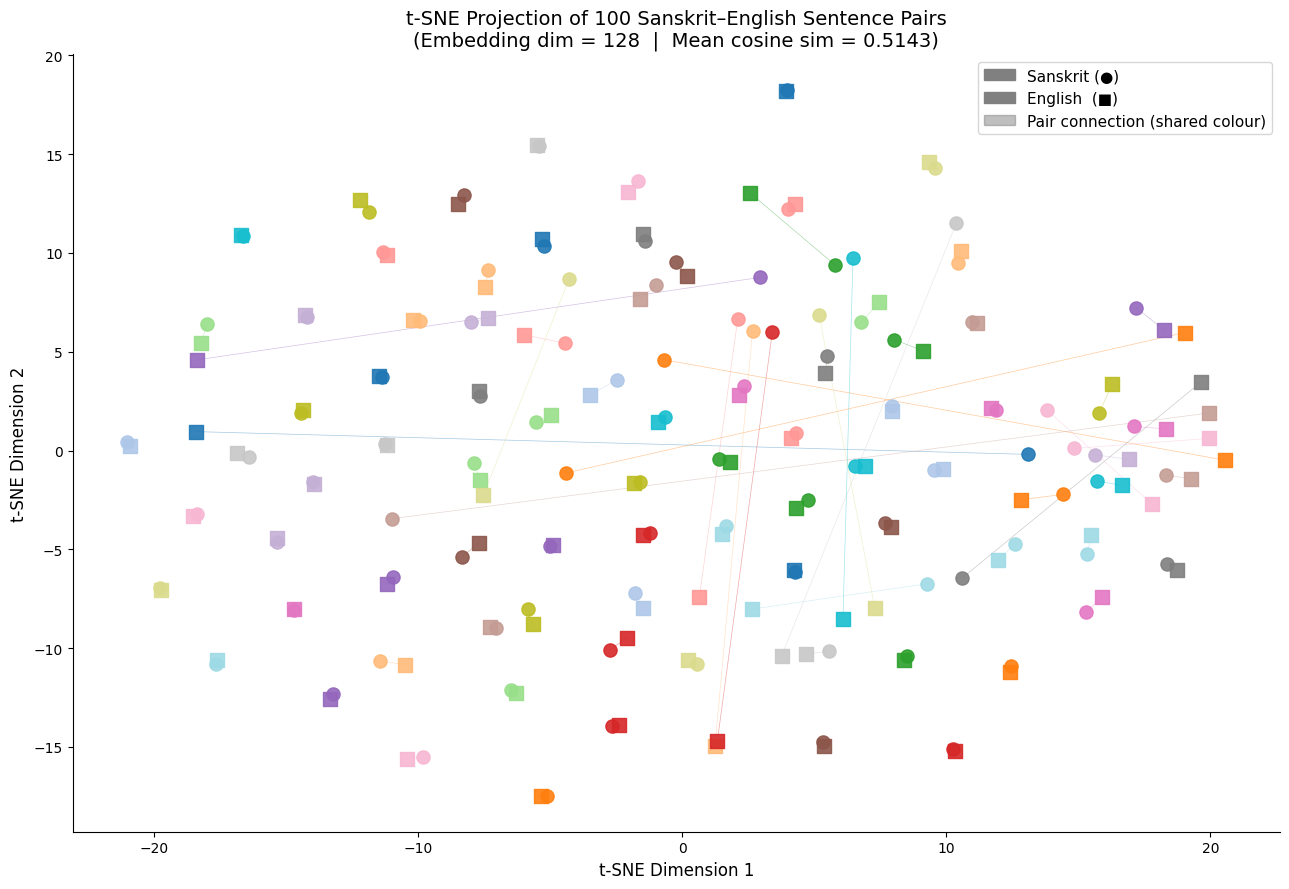

Plot saved to tsne_sanskrit_english.png


In [29]:
fig, ax = plt.subplots(figsize=(13, 9))
palette = plt.cm.tab20(np.linspace(0, 1, n_sample))

for i in range(n_sample):
    color = palette[i]
    # Sanskrit: filled circle
    ax.scatter(tsne_sa[i, 0], tsne_sa[i, 1],
               color=color, marker='o', s=90, zorder=3, alpha=0.9)
    # English: filled square
    ax.scatter(tsne_en[i, 0], tsne_en[i, 1],
               color=color, marker='s', s=90, zorder=3, alpha=0.9)
    # Line connecting the pair
    ax.plot([tsne_sa[i, 0], tsne_en[i, 0]],
            [tsne_sa[i, 1], tsne_en[i, 1]],
            color=color, linewidth=0.5, alpha=0.4, zorder=2)
# Legend
sa_patch = mpatches.Patch(color='gray', label='Sanskrit (●)')
en_patch = mpatches.Patch(color='gray', label='English  (■)')
line_patch = mpatches.Patch(color='gray', alpha=0.5,
                             label='Pair connection (shared colour)')
ax.legend(handles=[sa_patch, en_patch, line_patch],
          fontsize=11, loc='upper right')

ax.set_title(
    f't-SNE Projection of 100 Sanskrit–English Sentence Pairs\n'
    f'(Embedding dim = {target_dimension}  |  Mean cosine sim = {avg_cosine_similarity:.4f})',
    fontsize=14
)
ax.set_xlabel('t-SNE Dimension 1', fontsize=12)
ax.set_ylabel('t-SNE Dimension 2', fontsize=12)
sns.despine()
plt.tight_layout()
plt.savefig('tsne_sanskrit_english.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to tsne_sanskrit_english.png")

In [32]:

print(f"Model: LaBSE (sentence-transformers)")
print(f"Native dim: 768")
print(f"PCA reduction: 768 → {target_dimension}")
print(f"EMBEDDING DIMENSION: {target_dimension}")
print(f"Explained variance: {explained:.2f} %")
print(f"Total pairs: {len(df_all)}")
print(f"AVG COSINE SIM (all): {avg_cosine_similarity:.4f}")
print(f"AVG COSINE SIM (train): {cos_train.mean():.4f}")
print(f"AVG COSINE SIM (dev): {cos_dev.mean():.4f}")
print(f"AVG COSINE SIM (test): {cos_test.mean():.4f}")

Model: LaBSE (sentence-transformers)
Native dim: 768
PCA reduction: 768 → 128
EMBEDDING DIMENSION: 128
Explained variance: 84.27 %
Total pairs: 12000
AVG COSINE SIM (all): 0.5143
AVG COSINE SIM (train): 0.5143
AVG COSINE SIM (dev): 0.5167
AVG COSINE SIM (test): 0.5117
